# Modelo de difusión usando `diffusers`

In [ ]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from diffusers import DDPMPipeline

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Visualizador de imágenes

In [2]:
def show_images(x_t, t, T):

    img_batch = x_t.detach().cpu()
    grid = make_grid(img_batch, nrow=len(img_batch), normalize=True, value_range=(-1, 1))

    plt.figure(figsize=(8, 3))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(f'Paso de denoising: {t}/{T}')
    plt.axis('off')
    plt.show()

## Pipeline DDPM

In [3]:
pipeline = DDPMPipeline.from_pretrained('google/ddpm-celebahq-256').to(DEVICE)
scheduler = pipeline.scheduler

T = scheduler.config.num_train_timesteps

scheduler.set_timesteps(50)

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /workspace/.cache/huggingface/hub/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory /workspace/.cache/huggingface/hub/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


## Proceso de denoising

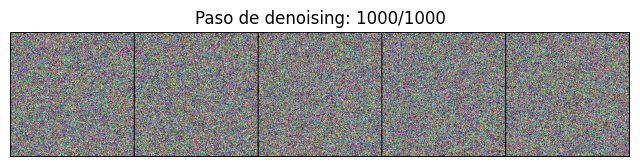

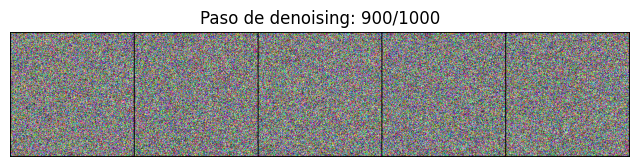

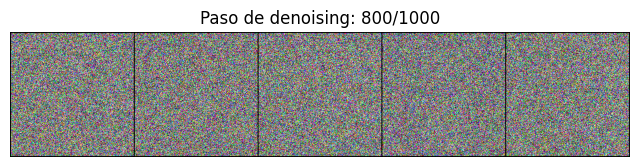

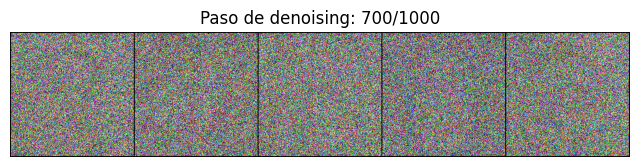

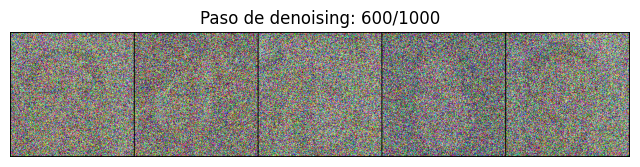

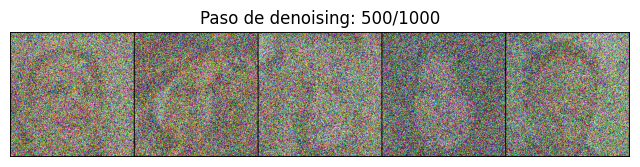

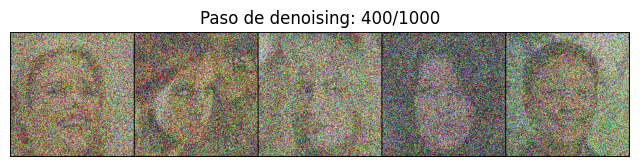

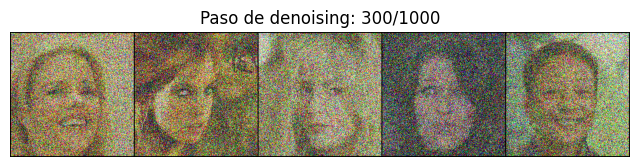

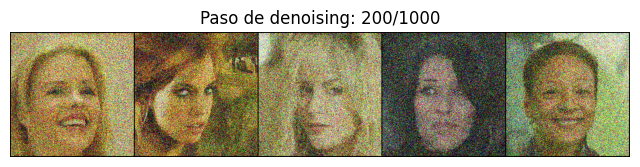

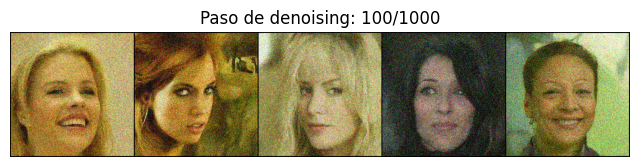

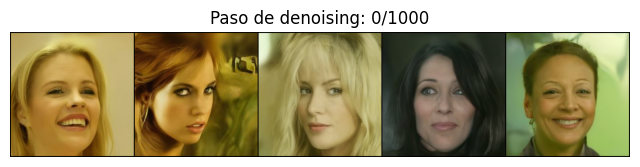

In [4]:
batch_size = 5

x_t = torch.randn(batch_size, 3, 256, 256).to(DEVICE)
show_images(x_t, T, T)

for n_iter, t in enumerate(scheduler.timesteps, start=1):

    # Denoising:
    with torch.no_grad():
        noise_pred = pipeline.unet(x_t, t)['sample']
        x_t = scheduler.step(noise_pred, t, x_t)['prev_sample']

    # Visualización:
    if n_iter % 5 == 0 or n_iter == len(scheduler.timesteps):
        show_images(x_t, t, T)